In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# loading dataset

In [3]:
df=pd.read_excel('pima-data1.xlsx')
df

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,diabetes_orig,skin,has_diabetes,diabetes
0,6,148,72,35,0,33.6,0.627,50,1,1.3790,True,True
1,1,85,66,29,0,26.6,0.351,31,0,1.1426,False,False
2,8,183,64,0,0,23.3,0.672,32,1,0.0000,True,True
3,1,89,66,23,94,28.1,0.167,21,0,0.9062,False,False
4,0,137,40,35,168,43.1,2.288,33,1,1.3790,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,1.8912,False,False
764,2,122,70,27,0,36.8,0.340,27,0,1.0638,False,False
765,5,121,72,23,112,26.2,0.245,30,0,0.9062,False,False
766,1,126,60,0,0,30.1,0.349,47,1,0.0000,True,True


In [4]:
df.shape

(768, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   num_preg       768 non-null    int64  
 1   glucose_conc   768 non-null    int64  
 2   diastolic_bp   768 non-null    int64  
 3   thickness      768 non-null    int64  
 4   insulin        768 non-null    int64  
 5   bmi            768 non-null    float64
 6   diab_pred      768 non-null    float64
 7   age            768 non-null    int64  
 8   diabetes_orig  768 non-null    int64  
 9   skin           768 non-null    float64
 10  has_diabetes   768 non-null    bool   
 11  diabetes       768 non-null    bool   
dtypes: bool(2), float64(3), int64(7)
memory usage: 61.6 KB


# step2

In [7]:
df.isnull().sum()

num_preg         0
glucose_conc     0
diastolic_bp     0
thickness        0
insulin          0
bmi              0
diab_pred        0
age              0
diabetes_orig    0
skin             0
has_diabetes     0
diabetes         0
dtype: int64

# checking collection between two columns

In [9]:
def check_corr(size):
    corr=df.corr()
    fig,ax=plt.subplots(figsize=(size,size))
    ax.matshow(corr,cmap='magma')
    plt.xticks(range(len(corr.columns)),corr.columns,rotation=45)
    plt.yticks(range(len(corr.columns)),corr.columns)
    plt.show()

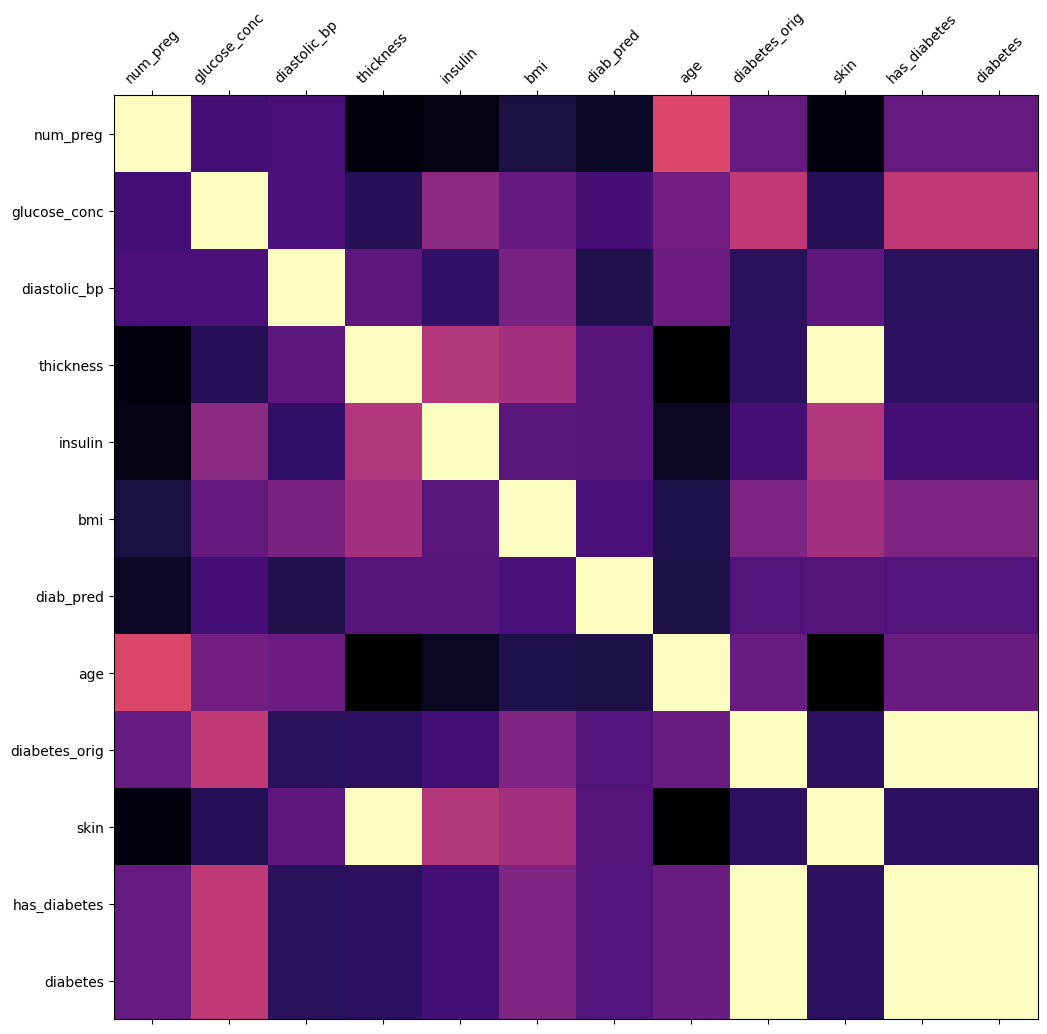

In [10]:
check_corr(12)

In [11]:
df.corr()

,num_preg,glucose_conc,diastolic_bp,thickness,insulin,bmi,diab_pred,age,diabetes_orig,skin,has_diabetes,diabetes
num_preg,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898,-0.081672,0.221898,0.221898
glucose_conc,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581,0.057328,0.466581,0.466581
diastolic_bp,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068,0.207371,0.065068,0.065068
thickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752,1.000000,0.074752,0.074752
insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548,0.436783,0.130548,0.130548
bmi,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695,0.392573,0.292695,0.292695
diab_pred,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844,0.183928,0.173844,0.173844
age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356,-0.113970,0.238356,0.238356
diabetes_orig,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000,0.074752,1.000000,1.000000
skin,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752,1.000000,0.074752,0.074752


In [12]:
# thickness and skill are correlated to each other
# diabetics_orig has diabetics are corelated to each other
# diabetics_orig diabetics are corelated to each other
# has_diabetics and diabetics are corelated to each other

In [13]:
df.drop('thickness',axis=1,inplace=True)
df.drop('diabetes_orig',axis=1,inplace=True)


In [14]:
df.drop('has_diabetes',axis=1,inplace=True)

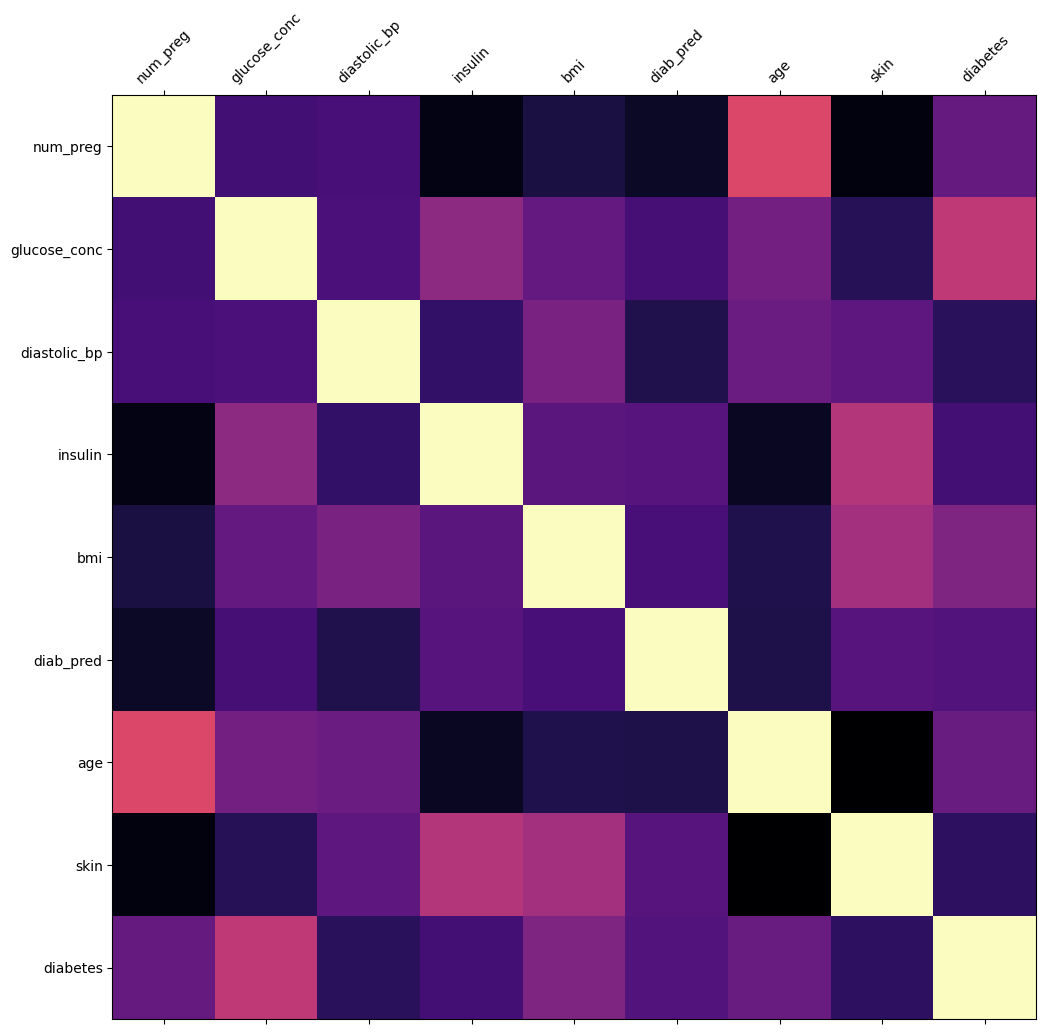

In [15]:
check_corr(12)

# 4.convert string data to integer type

In [17]:
df['diabetes'].unique()

array([ True, False])

In [18]:
df['diabetes']=df['diabetes'].map({True:1,False:0})
df.head()

,num_preg,glucose_conc,diastolic_bp,insulin,bmi,diab_pred,age,skin,diabetes
0,6,148,72,0,33.6,0.627,50,1.3790,1
1,1,85,66,0,26.6,0.351,31,1.1426,0
2,8,183,64,0,23.3,0.672,32,0.0000,1
3,1,89,66,94,28.1,0.167,21,0.9062,0
4,0,137,40,168,43.1,2.288,33,1.3790,1


# 5 check prporties of data

In [20]:
num_true=len(df.loc[df['diabetes']==1])
num_false=len(df.loc[df['diabetes']==0])
print(f'num of true data is {num_true}')
print(f'num of false data is {num_false}')

num of true data is 268
num of false data is 500


In [21]:
true_percentage=(num_true/(num_true+num_false))*100
false_percentage=(num_false/(num_true+num_false))*100
print(f'num of true percentage is {true_percentage}')
print(f'num of false percentage is {false_percentage}')

num of true percentage is 34.89583333333333
num of false percentage is 65.10416666666666


# step3 train test splt

In [23]:
df.columns

Index(['num_preg', 'glucose_conc', 'diastolic_bp', 'insulin', 'bmi',
       'diab_pred', 'age', 'skin', 'diabetes'],
      dtype='object')

In [24]:
inp_columns=['num_preg', 'glucose_conc', 'diastolic_bp', 'insulin', 'bmi',
       'diab_pred', 'age', 'skin']
out_columns=['diabetes']
    

In [25]:
x=df[inp_columns].values
y=df[out_columns].values

## pip install -U scikit-learn

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [29]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(537, 8)
(231, 8)
(537, 1)
(231, 1)


#  check training testing percentage after test

In [31]:
df.columns

Index(['num_preg', 'glucose_conc', 'diastolic_bp', 'insulin', 'bmi',
       'diab_pred', 'age', 'skin', 'diabetes'],
      dtype='object')

In [32]:
from sklearn.impute import SimpleImputer

In [33]:
x_train[:5]

array([[1.0000e+00, 9.5000e+01, 6.0000e+01, 5.8000e+01, 2.3900e+01,
        2.6000e-01, 2.2000e+01, 7.0920e-01],
       [5.0000e+00, 1.0500e+02, 7.2000e+01, 3.2500e+02, 3.6900e+01,
        1.5900e-01, 2.8000e+01, 1.1426e+00],
       [0.0000e+00, 1.3500e+02, 6.8000e+01, 2.5000e+02, 4.2300e+01,
        3.6500e-01, 2.4000e+01, 1.6548e+00],
       [4.0000e+00, 1.3100e+02, 6.8000e+01, 1.6600e+02, 3.3100e+01,
        1.6000e-01, 2.8000e+01, 8.2740e-01],
       [1.0000e+00, 1.0300e+02, 3.0000e+01, 8.3000e+01, 4.3300e+01,
        1.8300e-01, 3.3000e+01, 1.4972e+00]])

In [34]:
fill_zeros=SimpleImputer(missing_values=0,strategy='mean')
x_train=fill_zeros.fit_transform(x_train)
x_test=fill_zeros.fit_transform(x_test)


In [35]:
x_test[:5]

array([[6.00000000e+00, 9.80000000e+01, 5.80000000e+01, 1.90000000e+02,
        3.40000000e+01, 4.30000000e-01, 4.30000000e+01, 1.30020000e+00],
       [2.00000000e+00, 1.12000000e+02, 7.50000000e+01, 1.56050847e+02,
        3.57000000e+01, 1.48000000e-01, 2.10000000e+01, 1.26080000e+00],
       [2.00000000e+00, 1.08000000e+02, 6.40000000e+01, 1.56050847e+02,
        3.08000000e+01, 1.58000000e-01, 2.10000000e+01, 1.19696203e+00],
       [8.00000000e+00, 1.07000000e+02, 8.00000000e+01, 1.56050847e+02,
        2.46000000e+01, 8.56000000e-01, 3.40000000e+01, 1.19696203e+00],
       [7.00000000e+00, 1.36000000e+02, 9.00000000e+01, 1.56050847e+02,
        2.99000000e+01, 2.10000000e-01, 5.00000000e+01, 1.19696203e+00]])

In [36]:
print('{0:0.2f} % in training set'.format((len(x_train)/len(df.index))*100))
print('{0:0.2f} % in testing set'.format((len(x_test)/len(df.index))*100))

69.92 % in training set
30.08 % in testing set


In [37]:
print('training true :{0} ({1:0.2f}%)'.format(len(y_train[y_train[:]==1]),((len(y_train[y_train[:]==1])/len(y_train))*100)))
print('training false :{0} ({1:0.2f}%)'.format(len(y_train[y_train[:]==0]),((len(y_train[y_train[:]==0])/len(y_train))*100)))

training true :188 (35.01%)
training false :349 (64.99%)


In [38]:
print('testing true :{0} ({1:0.2f}%)'.format(len(y_test[y_test[:]==1]),((len(y_test[y_test[:]==1])/len(y_test))*100)))
print('testing false :{0} ({1:0.2f}%)'.format(len(y_test[y_test[:]==0]),((len(y_test[y_test[:]==0])/len(y_test))*100)))

testing true :80 (34.63%)
testing false :151 (65.37%)


# step5:post split preparation

In [40]:
df.columns

Index(['num_preg', 'glucose_conc', 'diastolic_bp', 'insulin', 'bmi',
       'diab_pred', 'age', 'skin', 'diabetes'],
      dtype='object')

In [41]:
total_num_preg=len(df.loc[df['num_preg']==0])
print(f"total num of rows missing in num_preg column is {total_num_preg}")

total_glucose_conc=len(df.loc[df['glucose_conc']==0])
print(f"total num of rows missing in glucose_conc column is {total_glucose_conc}")

total_diastolic_bp=len(df.loc[df['diastolic_bp']==0])
print(f"total num of rows missing in diastolic_bp column is {total_diastolic_bp}")

total_insulin=len(df.loc[df['insulin']==0])
print(f"total num of rows missing in insulin column is {total_insulin}")

total_bmi=len(df.loc[df['bmi']==0])
print(f"total num of rows missing in bmi column is {total_bmi}")

total_diab_pred=len(df.loc[df['diab_pred']==0])
print(f"total num of rows missing in diab_pred column is {total_diab_pred}")

total_age=len(df.loc[df['age']==0])
print(f"total num of rows missing in age column is {total_age}")

total_skin=len(df.loc[df['skin']==0])
print(f"total num of rows missing in skin column is {total_skin}")


total num of rows missing in num_preg column is 111
total num of rows missing in glucose_conc column is 5
total num of rows missing in diastolic_bp column is 35
total num of rows missing in insulin column is 374
total num of rows missing in bmi column is 11
total num of rows missing in diab_pred column is 0
total num of rows missing in age column is 0
total num of rows missing in skin column is 227


# standadize the data

In [43]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
x_train=scalar.fit_transform(x_train)
x_test=scalar.fit_transform(x_test)

In [44]:
x_train[:5]

array([[-1.15687814e+00, -8.96200501e-01, -1.00392807e+00,
        -1.14563966e+00, -1.20379368e+00, -6.14216360e-01,
        -9.48610283e-01, -1.25782829e+00],
       [ 2.28370750e-01, -5.64089421e-01, -1.97904130e-02,
         1.99702256e+00,  6.64529988e-01, -9.09737865e-01,
        -4.34666726e-01,  4.16397301e-02],
       [ 6.15174086e-16,  4.32243819e-01, -3.47836300e-01,
         1.11425228e+00,  1.44060290e+00, -3.06991033e-01,
        -7.77295764e-01,  1.57737467e+00],
       [-1.17941473e-01,  2.99399387e-01, -3.47836300e-01,
         1.25549552e-01,  1.18404607e-01, -9.06811910e-01,
        -4.34666726e-01, -9.03427923e-01],
       [-1.15687814e+00, -6.30511637e-01, -3.46427222e+00,
        -8.51382901e-01,  1.58432010e+00, -8.39514933e-01,
        -6.38042901e-03,  1.10484084e+00]])

# step 6 train the model using navie bayes

In [46]:
from sklearn.naive_bayes import GaussianNB
nb_model=GaussianNB()
nb_model.fit(x_train,y_train.ravel())

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [47]:
from sklearn import metrics
nb_predict_model=nb_model.predict(x_train)
print(f'predicted accuracy for training dataa{metrics.accuracy_score(y_train,nb_predict_model)}')

predicted accuracy for training dataa0.7541899441340782


In [48]:
nb_predict_test=nb_model.predict(x_test)
print(f'predicted accuracy for training dataa{metrics.accuracy_score(y_test,nb_predict_test)}')

predicted accuracy for training dataa0.7532467532467533


# step6:test accuracy using confusion matrix

In [50]:
print(f"{metrics.confusion_matrix(y_test,nb_predict_test)}")

[[123  28]
 [ 29  51]]


# test accuracy using classification report

In [52]:
print(f"{metrics.classification_report(y_test,nb_predict_test)}")

              precision    recall  f1-score   support

           0       0.81      0.81      0.81       151
           1       0.65      0.64      0.64        80

    accuracy                           0.75       231
   macro avg       0.73      0.73      0.73       231
weighted avg       0.75      0.75      0.75       231



# train the model using random forest

In [54]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier(random_state=42)
rf_model.fit(x_train,y_train.ravel())

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [55]:
from sklearn import metrics
rf_predict_model=rf_model.predict(x_train)

print(f"predicted accuracy for training data {metrics.accuracy_score(y_train,rf_predict_model)}")

predicted accuracy for training data 1.0


In [56]:
rf_predict_test=rf_model.predict(x_test)

print(f"predicted accuracy for training data {metrics.accuracy_score(y_test,rf_predict_test)}")

predicted accuracy for training data 0.7402597402597403


In [57]:
print(f"{metrics.confusion_matrix(y_test,rf_predict_test)}")

[[121  30]
 [ 30  50]]


In [58]:
print(f"{metrics.classification_report(y_test,rf_predict_test)}")

              precision    recall  f1-score   support

           0       0.80      0.80      0.80       151
           1       0.62      0.62      0.62        80

    accuracy                           0.74       231
   macro avg       0.71      0.71      0.71       231
weighted avg       0.74      0.74      0.74       231



# train model using KNN

In [60]:
from sklearn.neighbors import KNeighborsClassifier
k_neighbours=KNeighborsClassifier()
k_neighbours.fit(x_train,y_train.ravel())

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [61]:
from sklearn import metrics
k_predict_model=k_neighbours.predict(x_train)

print(f"predicted accuracy for training data {metrics.accuracy_score(y_train,k_predict_model)}")

predicted accuracy for training data 0.8379888268156425


In [62]:
k_predict_test=k_neighbours.predict(x_test)

print(f"predicted accuracy for training data {metrics.accuracy_score(y_test,k_predict_test)}")

predicted accuracy for training data 0.7012987012987013


In [63]:
print(f"{metrics.confusion_matrix(y_test,k_predict_test)}")

[[115  36]
 [ 33  47]]


In [64]:
print(f"{metrics.classification_report(y_test,k_predict_test)}")

              precision    recall  f1-score   support

           0       0.78      0.76      0.77       151
           1       0.57      0.59      0.58        80

    accuracy                           0.70       231
   macro avg       0.67      0.67      0.67       231
weighted avg       0.70      0.70      0.70       231



In [65]:
## conclusion: we had provided training using naive bayees and random forest and KNN
## we got Random forest is giving high accuracy compare to naive bayees and KNN
## so i will prefere Random forest model for my project


In [69]:
# input_data=[6,	148,	72,	0,	33.6,	0.627,	50,	1.3790]
input_data=[1,	85,	66,	0,	26.6,	0.351,	31,	1.1426]

input_array = np.asarray(input_data).reshape(1,-1)
print(input_array)
# Apply the same imputer and scaler to new data
input_array = fill_zeros.transform(input_array)
input_array = scalar.transform(input_array)
print(input_array)
prediction = rf_model.predict(input_array)
print("Prediction:", "Diabetic" if prediction[0] == 1 else "Not Diabetic")

[[ 1.     85.     66.      0.     26.6     0.351  31.      1.1426]]
[[-1.22881240e+00 -1.15739443e+00 -5.74701339e-01 -6.68915923e-16
  -9.46173661e-01 -4.11419777e-01 -2.20384599e-01 -1.46609095e-01]]
Prediction: Not Diabetic


In [75]:
import pickle
# Save model
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
# Save scaler
with open('scalar.pkl', 'wb') as f:
    pickle.dump(scalar, f)
# Save imputer
with open('imputer.pkl', 'wb') as f:
    pickle.dump(fill_zeros, f)